# Mission 16 Modeling

이 노트북은 MNIST 숫자 분류용 MLP 모델을 학습한 뒤, 같은 모델을 세 가지 형식으로 저장합니다.

- 기본 PyTorch 모델: `mission_16_mnist_mlp.pth`
- 양자화 PyTorch 모델: `mission_16_mnist_mlp_quantized.pth`
- ONNX 모델: `mission_16_mnist_mlp.onnx`

이 노트북이 필요한 이유는 “모델을 만들었다”에서 끝내지 않고, 실제 서비스나 다른 실행 환경에서 다시 사용할 수 있는 파일로 내보내는 과정을 검증하기 위해서입니다.

전체 흐름은 다음과 같습니다.

1. MNIST 데이터로 작은 MLP 모델을 학습합니다.
2. 학습된 모델을 PyTorch 기본 형식인 `.pth`로 저장합니다.
3. 같은 모델에 동적 양자화를 적용해서 더 작은 `.pth` 파일로 저장합니다.
4. PyTorch 밖에서도 실행할 수 있도록 ONNX 파일로 변환합니다.
5. 세 파일의 용량과 정확도를 비교합니다.


## 1. 환경과 경로 설정

이 셀은 작업 기준 폴더와 결과 저장 위치를 정하는 단계입니다.

노트북을 실행할 때마다 모델 파일과 보고서 이미지가 흩어지면 제출물을 정리하기 어렵습니다. 그래서 모델은 `mission-result/models`, 보고서 자료는 `report-assets`에 모으도록 경로를 먼저 고정합니다.

또한 재현 가능한 결과를 위해 random seed를 고정합니다. 같은 코드를 다시 실행했을 때 학습 결과가 크게 흔들리지 않도록 하기 위한 준비입니다.


In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import onnx
import onnxruntime as ort
import matplotlib.pyplot as plt

# 현재 노트북이 있는 제출 폴더를 기준 경로로 사용합니다.
# 이렇게 해야 노트북을 다른 컴퓨터에서 실행해도 상대 경로가 크게 흔들리지 않습니다.
BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / "mission-result" / "models"
DATA_DIR = BASE_DIR / "mission-result" / "data"
REPORT_ASSETS_DIR = BASE_DIR / "report-assets"

# 모델 파일, 데이터, 보고서 이미지를 저장할 폴더를 미리 만듭니다.
for path in [MODELS_DIR, DATA_DIR, REPORT_ASSETS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# 같은 코드를 다시 실행해도 비슷한 결과가 나오도록 random seed를 고정합니다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU가 있으면 학습은 GPU에서 하고, 없으면 CPU에서 실행합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("BASE_DIR:", BASE_DIR)
print("device:", device)
print("torch:", torch.__version__)
print("onnx:", onnx.__version__)
print("onnxruntime:", ort.__version__)


BASE_DIR: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민
device: cuda
torch: 2.5.1+cu121
onnx: 1.21.0
onnxruntime: 1.25.1


## 2. MNIST 데이터 준비

이 셀은 모델이 학습하고 평가할 데이터를 준비하는 단계입니다.

MNIST 이미지는 28x28 크기의 흑백 숫자 이미지입니다. PyTorch에서는 이미지 한 장을 `[채널, 높이, 너비]`, 여러 장을 묶은 batch를 `[batch, 채널, 높이, 너비]` 형태로 다룹니다. 그래서 여기서는 입력 shape를 `[batch, 1, 28, 28]`로 맞춥니다.

정규화는 학습 안정성을 위해 사용합니다. 픽셀 값을 그대로 쓰지 않고 MNIST의 평균과 표준편차 기준으로 변환하면 모델이 더 안정적으로 학습됩니다.


In [2]:
BATCH_SIZE = 256

# ToTensor는 이미지를 PyTorch Tensor로 바꾸고 픽셀 값을 0~1 범위로 만듭니다.
# Normalize는 MNIST의 평균/표준편차를 기준으로 입력 분포를 맞춥니다.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# 학습용 MNIST 데이터입니다. 모델의 가중치를 업데이트하는 데 사용합니다.
train_dataset = datasets.MNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=transform,
)

# 평가용 MNIST 데이터입니다. 학습이 잘 되었는지 확인하는 데 사용합니다.
test_dataset = datasets.MNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform,
)

# DataLoader는 데이터를 batch 단위로 묶어서 모델에 넣기 쉽게 해줍니다.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print("train samples:", len(train_dataset))
print("test samples:", len(test_dataset))
images, labels = next(iter(train_loader))
print("image batch shape:", tuple(images.shape))
print("label batch shape:", tuple(labels.shape))


train samples: 60000
test samples: 10000


image batch shape: (256, 1, 28, 28)
label batch shape: (256,)


## 3. MLP 모델 정의

이 셀은 이번 미션에서 변환할 기준 모델을 정의하는 단계입니다.

MLP는 이미지를 784개의 숫자로 펼친 뒤 `Linear` 계층을 통과시키는 단순한 신경망입니다. 이번 과제에서는 복잡한 모델을 만드는 것보다 `.pth`, 양자화 `.pth`, ONNX 변환을 안정적으로 성공시키는 것이 더 중요합니다.

`Linear` 계층 중심 모델을 선택한 이유는 동적 양자화를 적용하기 쉽기 때문입니다. 즉, 양자화 개념을 확인하기에 좋은 구조입니다.


In [3]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # MNIST 이미지는 [1, 28, 28] 형태이므로 Linear 계층에 넣기 전에 784개 값으로 펼칩니다.
        self.flatten = nn.Flatten()

        # Linear 계층 중심의 단순한 MLP입니다.
        # 이 구조는 동적 양자화 적용이 쉬워 이번 미션의 목적에 잘 맞습니다.
        self.classifier = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.classifier(x)

model = MNISTMLP().to(device)
print(model)
param_count = sum(p.numel() for p in model.parameters())
print("parameter count:", param_count)


MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
parameter count: 535818


## 4. 모델 학습과 평가 함수 준비

이 셀은 반복해서 사용할 학습/평가 함수를 미리 정의하는 단계입니다.

`train_one_epoch`는 모델을 한 번 학습시키는 함수이고, `evaluate_torch`는 모델의 정확도를 계산하는 함수입니다. 함수를 분리해두면 기본 모델과 양자화 모델을 같은 기준으로 평가할 수 있습니다.

정확도는 `모델이 맞힌 개수 / 전체 데이터 개수`로 계산합니다.


In [4]:
def evaluate_torch(model_to_eval, loader, device_for_eval):
    # 평가할 때는 dropout/batchnorm 같은 학습 전용 동작을 끄기 위해 eval 모드로 바꿉니다.
    model_to_eval.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    # 평가 단계에서는 가중치를 업데이트하지 않으므로 gradient 계산을 끕니다.
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device_for_eval)
            y = y.to(device_for_eval)
            logits = model_to_eval(x)
            loss = criterion(logits, y)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            total_loss += loss.item() * y.size(0)

    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
    }

def train_one_epoch(model_to_train, loader, optimizer, device_for_train):
    # train 모드는 모델이 학습용 동작을 하도록 설정합니다.
    model_to_train.train()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    total = 0

    for x, y in loader:
        x = x.to(device_for_train)
        y = y.to(device_for_train)

        # 이전 batch에서 계산된 gradient를 지우고 새 batch 기준으로 다시 계산합니다.
        optimizer.zero_grad(set_to_none=True)
        logits = model_to_train(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total += y.size(0)

    return total_loss / total


## 5. 기본 모델 학습

이 셀은 실제로 MNIST 데이터를 사용해 모델의 가중치를 학습하는 단계입니다.

여기서 만든 모델이 뒤 단계의 기준 모델이 됩니다. 즉, 양자화 모델과 ONNX 모델은 이 학습된 모델을 바탕으로 만들어집니다.

3 epoch만 학습하는 이유는 과제 목적이 최고 성능 달성이 아니라 모델 변환과 검증이기 때문입니다. MNIST는 단순한 데이터셋이라 3 epoch만으로도 변환 결과를 비교하기에 충분한 정확도가 나옵니다.


In [5]:
EPOCHS = 3
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []
start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    # 한 epoch 동안 전체 학습 데이터를 사용해 모델 가중치를 업데이트합니다.
    train_loss = train_one_epoch(model, train_loader, optimizer, device)

    # epoch마다 테스트 정확도를 확인해 모델이 정상적으로 학습되는지 봅니다.
    eval_result = evaluate_torch(model, test_loader, device)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "test_loss": eval_result["loss"],
        "test_accuracy": eval_result["accuracy"],
    }
    history.append(row)
    print(
        f"epoch={epoch} train_loss={train_loss:.4f} "
        f"test_loss={eval_result['loss']:.4f} test_accuracy={eval_result['accuracy']:.4f}"
    )

training_seconds = time.time() - start_time
print("training_seconds:", round(training_seconds, 2))

# 최종 기본 모델의 정확도입니다. 뒤에서 양자화/ONNX 모델과 비교 기준으로 사용합니다.
base_eval = evaluate_torch(model, test_loader, device)
print("base_eval:", base_eval)


epoch=1 train_loss=0.2786 test_loss=0.1182 test_accuracy=0.9638


epoch=2 train_loss=0.0966 test_loss=0.0883 test_accuracy=0.9727


epoch=3 train_loss=0.0632 test_loss=0.0779 test_accuracy=0.9762
training_seconds: 45.87


base_eval: {'loss': 0.07792908737678081, 'accuracy': 0.9762}


## 6. 기본 PyTorch 모델 저장

이 셀은 학습된 기본 모델을 PyTorch가 다시 읽을 수 있는 `.pth` 파일로 저장하는 단계입니다.

`.pth`는 PyTorch에서 가장 자연스럽게 쓰는 모델 저장 형식입니다. 여기서는 모델 구조 전체가 아니라 `state_dict`, 즉 학습된 가중치 묶음을 저장합니다.

나중에 이 파일을 다시 쓰려면 같은 모델 구조를 코드로 정의한 뒤, 저장된 가중치를 불러오면 됩니다.


In [6]:
BASE_MODEL_PATH = MODELS_DIR / "mission_16_mnist_mlp.pth"

# 저장과 변환은 CPU 모델 기준으로 진행하면 환경 차이를 줄일 수 있습니다.
model_cpu = model.to("cpu").eval()

# state_dict는 모델이 학습한 가중치와 bias 값을 담고 있습니다.
# 모델 구조는 코드에 있고, 실제 학습 결과는 이 파일에 저장됩니다.
torch.save(
    {
        "model_name": "mnist_mlp",
        "model_class": "MNISTMLP",
        "model_state_dict": model_cpu.state_dict(),
        "input_shape": [1, 1, 28, 28],
        "num_classes": 10,
        "normalize_mean": [0.1307],
        "normalize_std": [0.3081],
        "test_accuracy": base_eval["accuracy"],
    },
    BASE_MODEL_PATH,
)
print("saved:", BASE_MODEL_PATH)
print("size bytes:", BASE_MODEL_PATH.stat().st_size)


saved: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\mission-result\models\mission_16_mnist_mlp.pth
size bytes: 2145928


## 7. 양자화 모델 생성과 저장

이 셀은 기본 모델을 더 작은 모델로 바꾸는 양자화 단계입니다.

양자화는 모델 내부의 숫자를 더 적은 비트로 표현해 파일 크기나 CPU 추론 비용을 줄이는 방법입니다. 원래 가중치는 보통 `float32`인데, 동적 양자화는 `Linear` 계층의 가중치를 int8에 가까운 표현으로 바꿔 더 가볍게 만듭니다.

이번에는 학습을 다시 하지 않는 동적 양자화를 사용합니다. 그래서 빠르게 적용할 수 있고, 기본 모델과 양자화 모델의 용량과 정확도를 바로 비교할 수 있습니다.


In [7]:
QUANTIZED_MODEL_PATH = MODELS_DIR / "mission_16_mnist_mlp_quantized.pth"

# 동적 양자화는 주로 Linear 계층의 가중치를 더 작은 정수 표현으로 바꿉니다.
# 학습을 다시 하지 않고 적용할 수 있어 이번 과제처럼 변환 실습에 적합합니다.
quantized_model = torch.quantization.quantize_dynamic(
    model_cpu,
    {nn.Linear},
    dtype=torch.qint8,
).eval()

# 양자화 후에도 정확도가 유지되는지 CPU에서 평가합니다.
quant_eval = evaluate_torch(quantized_model, test_loader, torch.device("cpu"))

# 양자화 모델은 기본 모델과 내부 모듈 타입이 다르므로, 양자화된 state_dict를 따로 저장합니다.
torch.save(
    {
        "model_name": "mnist_mlp_quantized_dynamic",
        "model_class": "MNISTMLP",
        "quantization": "dynamic int8 for nn.Linear",
        "model_state_dict": quantized_model.state_dict(),
        "input_shape": [1, 1, 28, 28],
        "num_classes": 10,
        "normalize_mean": [0.1307],
        "normalize_std": [0.3081],
        "test_accuracy": quant_eval["accuracy"],
    },
    QUANTIZED_MODEL_PATH,
)
print("quant_eval:", quant_eval)
print("saved:", QUANTIZED_MODEL_PATH)
print("size bytes:", QUANTIZED_MODEL_PATH.stat().st_size)


quant_eval: {'loss': 0.07777645960282534, 'accuracy': 0.9761}
saved: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\mission-result\models\mission_16_mnist_mlp_quantized.pth
size bytes: 542962


## 8. ONNX 모델 변환과 검증

이 셀은 PyTorch 모델을 ONNX 형식으로 변환하는 단계입니다.

ONNX는 서로 다른 딥러닝 프레임워크와 실행 환경 사이에서 모델을 주고받기 위한 공통 형식입니다. PyTorch에서 학습한 모델을 ONNX로 변환하면 Python/PyTorch가 없는 환경에서도 ONNX Runtime 같은 도구로 실행할 수 있습니다.

변환만 하고 끝내면 안 됩니다. 그래서 ONNX 파일을 저장한 뒤 `onnx.checker`로 파일이 유효한지 검사하고, ONNX Runtime으로 실제 추론 정확도까지 확인합니다.


In [8]:
ONNX_MODEL_PATH = MODELS_DIR / "mission_16_mnist_mlp.onnx"

# ONNX export는 모델에 어떤 모양의 입력이 들어가는지 알아야 합니다.
# 그래서 실제 데이터와 같은 shape의 더미 입력을 하나 준비합니다.
dummy_input = torch.randn(1, 1, 28, 28, dtype=torch.float32)

torch.onnx.export(
    model_cpu,
    dummy_input,
    ONNX_MODEL_PATH,
    input_names=["input"],
    output_names=["logits"],
    # batch 크기는 1개일 수도 있고 여러 개일 수도 있으므로 동적 축으로 지정합니다.
    dynamic_axes={"input": {0: "batch_size"}, "logits": {0: "batch_size"}},
    opset_version=17,
)

# ONNX 파일이 형식상 유효한지 검사합니다.
onnx_model = onnx.load(str(ONNX_MODEL_PATH))
onnx.checker.check_model(onnx_model)
print("saved:", ONNX_MODEL_PATH)
print("size bytes:", ONNX_MODEL_PATH.stat().st_size)
print("onnx check: OK")


saved: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\mission-result\models\mission_16_mnist_mlp.onnx
size bytes: 2144478
onnx check: OK


In [9]:
def evaluate_onnx(onnx_path, loader):
    # ONNX Runtime은 PyTorch 없이 ONNX 모델을 실행하는 추론 엔진입니다.
    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    correct = 0
    total = 0

    for x, y in loader:
        # ONNX Runtime은 numpy 배열을 입력으로 받습니다.
        x_np = x.numpy().astype(np.float32)
        logits = session.run([output_name], {input_name: x_np})[0]
        pred = logits.argmax(axis=1)
        correct += int((pred == y.numpy()).sum())
        total += len(y)

    return {"accuracy": correct / total}

# ONNX로 변환된 모델이 실제로 추론 가능한지 정확도를 계산합니다.
onnx_eval = evaluate_onnx(ONNX_MODEL_PATH, test_loader)
print("onnx_eval:", onnx_eval)


onnx_eval: {'accuracy': 0.9762}


## 9. 세 모델의 용량과 정확도 비교

이 셀은 과제 보고서에 들어갈 핵심 결과를 정리하는 단계입니다.

기본 `.pth`, 양자화 `.pth`, ONNX 파일은 같은 모델에서 나온 결과물이지만 저장 방식과 용도가 다릅니다. 따라서 단순히 파일을 만들었다고 끝내지 않고, 용량과 정확도를 함께 비교해야 합니다.

특히 양자화 모델은 기본 모델보다 얼마나 작아졌는지, 정확도는 얼마나 유지되었는지를 확인하는 것이 중요합니다.


In [10]:
def file_size_info(path):
    # 파일 크기를 bytes, KB, MB 단위로 함께 계산합니다.
    size_bytes = path.stat().st_size
    return {
        "file_name": path.name,
        "size_bytes": size_bytes,
        "size_kb": size_bytes / 1024,
        "size_mb": size_bytes / (1024 * 1024),
    }

rows = []
for label, path, eval_result in [
    ("PyTorch pth", BASE_MODEL_PATH, base_eval),
    ("Quantized pth", QUANTIZED_MODEL_PATH, quant_eval),
    ("ONNX", ONNX_MODEL_PATH, onnx_eval),
]:
    info = file_size_info(path)
    info["model_type"] = label
    info["accuracy"] = eval_result["accuracy"]
    rows.append(info)

# 모델별 용량과 정확도를 표 형태로 정리합니다.
comparison_df = pd.DataFrame(rows)[[
    "model_type",
    "file_name",
    "size_bytes",
    "size_kb",
    "size_mb",
    "accuracy",
]]
comparison_df["size_kb"] = comparison_df["size_kb"].round(2)
comparison_df["size_mb"] = comparison_df["size_mb"].round(4)
comparison_df["accuracy"] = comparison_df["accuracy"].round(4)

comparison_csv = REPORT_ASSETS_DIR / "mission16_model_comparison.csv"
comparison_df.to_csv(comparison_csv, index=False, encoding="utf-8-sig")
print("saved comparison csv:", comparison_csv)
display(comparison_df)


saved comparison csv: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\report-assets\mission16_model_comparison.csv


,model_type,file_name,size_bytes,size_kb,size_mb,accuracy
0,PyTorch pth,mission_16_mnist_mlp.pth,2145928,2095.63,2.0465,0.9762
1,Quantized pth,mission_16_mnist_mlp_quantized.pth,542962,530.24,0.5178,0.9761
2,ONNX,mission_16_mnist_mlp.onnx,2144478,2094.22,2.0451,0.9762


saved comparison image: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\report-assets\mission16_model_size_comparison.png


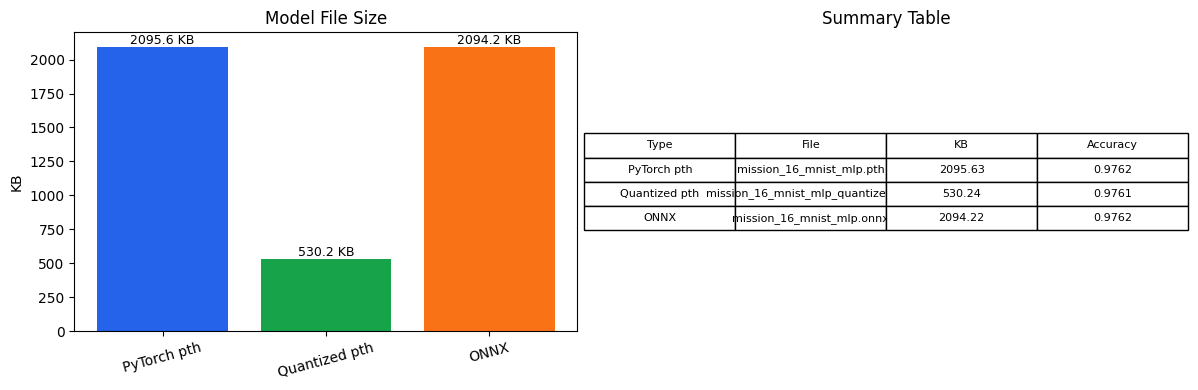

In [11]:
# 보고서에 바로 넣을 수 있도록 모델 용량 그래프와 요약 표를 이미지로 저장합니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparison_df["model_type"], comparison_df["size_kb"], color=["#2563eb", "#16a34a", "#f97316"])
axes[0].set_title("Model File Size")
axes[0].set_ylabel("KB")
axes[0].tick_params(axis="x", rotation=15)
for idx, value in enumerate(comparison_df["size_kb"]):
    axes[0].text(idx, value, f"{value:.1f} KB", ha="center", va="bottom", fontsize=9)

axes[1].axis("off")
table_data = comparison_df[["model_type", "file_name", "size_kb", "accuracy"]].copy()
table_data["size_kb"] = table_data["size_kb"].map(lambda x: f"{x:.2f}")
table_data["accuracy"] = table_data["accuracy"].map(lambda x: f"{x:.4f}")
table = axes[1].table(
    cellText=table_data.values,
    colLabels=["Type", "File", "KB", "Accuracy"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)
axes[1].set_title("Summary Table")

fig.tight_layout()
comparison_png = REPORT_ASSETS_DIR / "mission16_model_size_comparison.png"
fig.savefig(comparison_png, dpi=180, bbox_inches="tight")
print("saved comparison image:", comparison_png)
plt.show()


## 10. 모델 저장 결과 요약 파일 생성

이 셀은 모델링 결과를 JSON으로 저장하는 단계입니다.

JSON 요약 파일을 만들어두면 보고서 작성이나 추론 노트북에서 결과를 다시 확인하기 쉽습니다. 사람이 보는 표와 이미지뿐 아니라, 코드가 다시 읽을 수 있는 구조화된 결과도 남겨두는 목적입니다.


In [12]:
# 모델링 결과를 JSON으로 저장해두면 보고서나 다른 노트북에서 다시 활용하기 쉽습니다.
summary = {
    "model": "MNISTMLP",
    "dataset": "MNIST",
    "epochs": EPOCHS,
    "training_seconds": training_seconds,
    "base_model": {
        "path": str(BASE_MODEL_PATH.relative_to(BASE_DIR)),
        "accuracy": base_eval["accuracy"],
        "size_bytes": BASE_MODEL_PATH.stat().st_size,
    },
    "quantized_model": {
        "path": str(QUANTIZED_MODEL_PATH.relative_to(BASE_DIR)),
        "accuracy": quant_eval["accuracy"],
        "size_bytes": QUANTIZED_MODEL_PATH.stat().st_size,
        "quantization": "dynamic int8 for nn.Linear",
    },
    "onnx_model": {
        "path": str(ONNX_MODEL_PATH.relative_to(BASE_DIR)),
        "accuracy": onnx_eval["accuracy"],
        "size_bytes": ONNX_MODEL_PATH.stat().st_size,
    },
}

summary_path = REPORT_ASSETS_DIR / "mission16_modeling_summary.json"
with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))
print("saved summary:", summary_path)


{
  "model": "MNISTMLP",
  "dataset": "MNIST",
  "epochs": 3,
  "training_seconds": 45.87230467796326,
  "base_model": {
    "path": "mission-result\\models\\mission_16_mnist_mlp.pth",
    "accuracy": 0.9762,
    "size_bytes": 2145928
  },
  "quantized_model": {
    "path": "mission-result\\models\\mission_16_mnist_mlp_quantized.pth",
    "accuracy": 0.9761,
    "size_bytes": 542962,
    "quantization": "dynamic int8 for nn.Linear"
  },
  "onnx_model": {
    "path": "mission-result\\models\\mission_16_mnist_mlp.onnx",
    "accuracy": 0.9762,
    "size_bytes": 2144478
  }
}
saved summary: C:\Users\amy\Desktop\sprint\sprint_ai07\미션\미션16\4팀_김도민\report-assets\mission16_modeling_summary.json
